# Tier 2: Generative ML (Gaussian Naive Bayes)

**CSCI 575 | Privacy-Preserving Record Linkage**

The first ML tier.

Each per-field similarity is treated as independent given the match label, with class-conditional Gaussians fit by MLE.

Same 8 features, same 80/20 split, same 100k test set as the other tiers; only the classifier changes.

In [1]:
import pandas as pd
from sklearn.naive_bayes      import GaussianNB
from sklearn.model_selection  import train_test_split

from utils import (
    FEATURE_NAMES,
    load_candidates, build_feature_matrix,
    compute_metrics, print_metrics, save_metrics,
    plot_score_distribution,
    save_example_pair_predictions,
)

THRESHOLD   = 0.50
RANDOM_SEED = 42  

## Load Data and Build Feature Matrix

In [2]:
candidates              = load_candidates()
field_similarity_scores = build_feature_matrix(candidates)

print(f'{len(candidates):,} candidate pairs  '
      f'({candidates["is_match"].sum():,} matches, '
      f'{(~candidates["is_match"]).sum():,} non-matches)')

500,000 candidate pairs  (50,000 matches, 450,000 non-matches)


## Fit Gaussian Naive Bayes

80/20 split with the shared `random_state = 42`. 


In [3]:
labels = candidates['is_match'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    field_similarity_scores,
    labels,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=labels,
)

model = GaussianNB()
model.fit(X_train, y_train)

class_means = pd.DataFrame(model.theta_, columns=FEATURE_NAMES, index=['non-match', 'match']).round(3)
print('Per-feature class-conditional means:')
print(class_means.to_string())

Per-feature class-conditional means:
           first_name  last_name  street_address  date_of_birth  email  zip_code  state  phone
non-match       0.345      0.327           0.471          0.708  0.466     0.000  0.017  0.000
match           0.886      0.884           0.894          0.993  0.715     0.731  1.000  0.596


## Predict on All Candidates

Probabilities for every pair so the comparison notebook can look up the example pairs. Metrics use only the 20% test split.

In [4]:
candidates['match_probability'] = model.predict_proba(field_similarity_scores)[:, 1]
candidates['predicted_match']   = (candidates['match_probability'] >= THRESHOLD).astype(int)

test_candidates = candidates.loc[X_test.index]

(test_candidates[['rec_id_a', 'rec_id_b', 'is_match', 'match_probability', 'predicted_match']]
    .round({'match_probability': 3})
    .head(10))

,rec_id_a,rec_id_b,is_match,match_probability,predicted_match
84492,16243,45003,False,0.0,0
282042,4223,18009,False,0.0,0
478886,21025,48009,False,0.0,0
263682,40414,32578,False,0.0,0
43310,43310,43310,True,1.0,1
34983,34983,34983,True,1.0,1
250034,21288,17215,False,0.0,0
117381,6264,12465,False,0.0,0
210082,47010,29660,False,0.0,0
123135,14943,42957,False,0.0,0


## Evaluate

In [5]:
metrics = compute_metrics(
    tier_name        = 'T2_naive_bayes',
    true_labels      = test_candidates['is_match'].astype(int),
    predicted_labels = test_candidates['predicted_match'],
    scores           = test_candidates['match_probability'],
    threshold        = THRESHOLD,
    n_pairs          = len(test_candidates),
)
print_metrics(metrics)

Precision : 0.9992
Recall    : 1.0000
F1        : 0.9996
AUC-ROC   : 1.0000
Threshold : 0.5
N pairs   : 100,000


## Probability Distribution

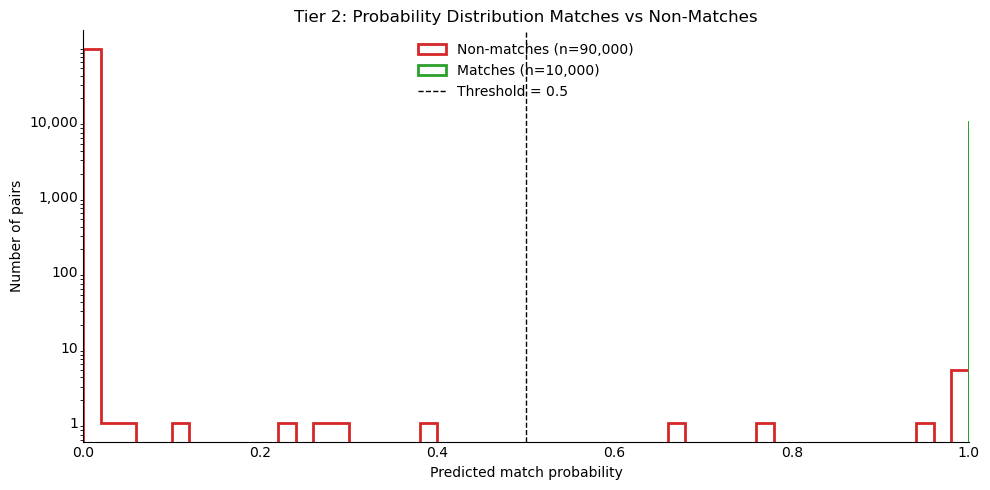

In [6]:
plot_score_distribution(
    match_scores     = test_candidates.loc[test_candidates['is_match'],  'match_probability'],
    non_match_scores = test_candidates.loc[~test_candidates['is_match'], 'match_probability'],
    threshold        = THRESHOLD,
    title            = 'Tier 2: Probability Distribution Matches vs Non-Matches',
    x_label          = 'Predicted match probability',
    filename         = 'tier2_score_distribution.png',
)

## Save Results

In [7]:
save_metrics(metrics, 'tier2_metrics.csv')
save_example_pair_predictions(candidates, 'T2_naive_bayes', 'match_probability', 'tier2_example_predictions.csv')